In [12]:
!pip install numpy pandas
!pip install matplotlib
!pip install torch

   ---------------------------------------- 0.0/114.6 MB ? eta -:--:--
    --------------------------------------- 2.6/114.6 MB 13.0 MB/s eta 0:00:09
   - -------------------------------------- 5.0/114.6 MB 13.0 MB/s eta 0:00:09
   -- ------------------------------------- 7.9/114.6 MB 12.9 MB/s eta 0:00:09
   --- ------------------------------------ 10.5/114.6 MB 12.9 MB/s eta 0:00:09
   ---- ----------------------------------- 13.1/114.6 MB 12.9 MB/s eta 0:00:08
   ----- ---------------------------------- 15.7/114.6 MB 12.9 MB/s eta 0:00:08
   ------ --------------------------------- 18.4/114.6 MB 12.9 MB/s eta 0:00:08
   ------- -------------------------------- 21.0/114.6 MB 12.9 MB/s eta 0:00:08
   -------- ------------------------------- 23.6/114.6 MB 12.9 MB/s eta 0:00:08
   --------- ------------------------------ 26.2/114.6 MB 12.9 MB/s eta 0:00:07
   ---------- ----------------------------- 28.8/114.6 MB 12.9 MB/s eta 0:00:07
   ---------- ----------------------------- 31.5/114

In [9]:
import numpy as np
import pandas as pd

g = -9.8          # Schwerkraft
dt = 0.01         # Zeitschritt
steps = 500       # Schritte pro Simulation

data = []        

# simulieren
for sim in range(30):

    x = np.random.uniform(0.5, 3.0)     # Höhe
    v = np.random.uniform(-1.0, 1.0)    # Geschwindigkeit
    restitution = np.random.uniform(0.6, 0.9)  # wie stark er zurückspringt

    for t in range(steps):
        x_old = x
        v_old = v

        v = v + g * dt
        x = x + v * dt

        if x <= 0:
            x = 0
            v = -restitution * v

        x_next = x
        v_next = v

        data.append([x_old, v_old, x_next, v_next])

df = pd.DataFrame(data, columns=["x", "v", "x_next", "v_next"])

# speichern als Datei
df.to_csv("bouncing_ball_data.csv", index=False)

print(len(df))
print("Datensatz gespeichert!")

15000
Datensatz gespeichert!


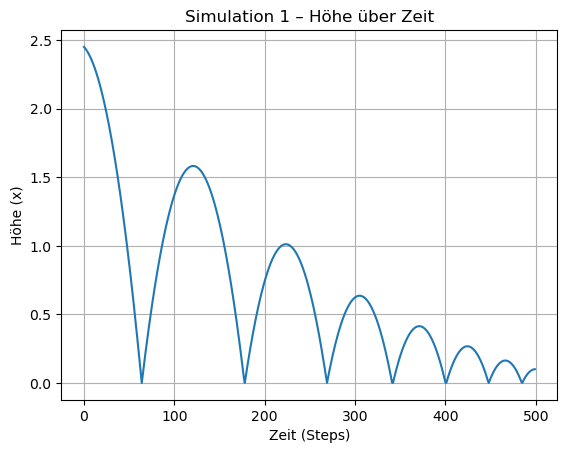

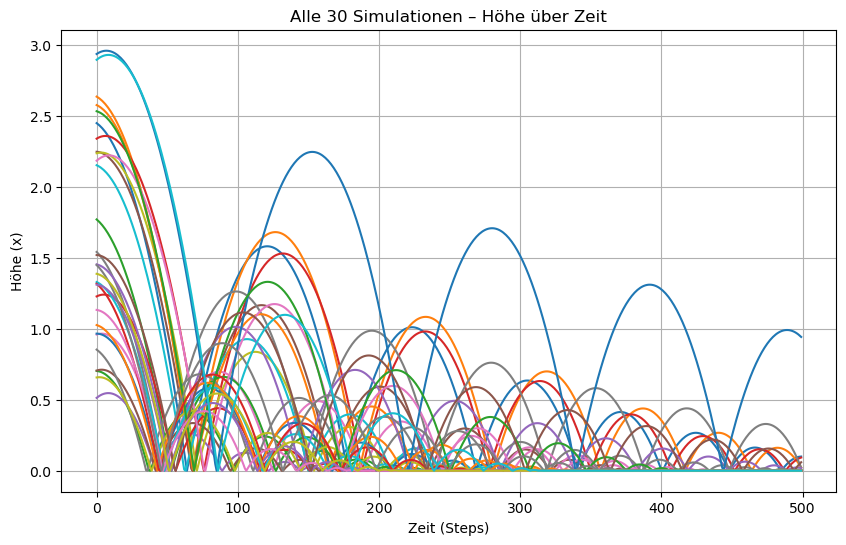

In [10]:
import matplotlib.pyplot as plt

sim1 = df.iloc[:500]
time = range(len(sim1))

plt.plot(time, sim1["x"])
plt.xlabel("Zeit (Steps)")
plt.ylabel("Höhe (x)")
plt.title("Simulation 1 – Höhe über Zeit")
plt.grid()

plt.show()

steps_per_sim = 500
num_sims = 30

plt.figure(figsize=(10, 6))

for sim in range(num_sims):
    start = sim * steps_per_sim
    end = (sim + 1) * steps_per_sim
    
    sim_data = df.iloc[start:end]
    time = range(len(sim_data))
    
    plt.plot(time, sim_data["x"], label=f"Sim {sim+1}")

plt.xlabel("Zeit (Steps)")
plt.ylabel("Höhe (x)")
plt.title("Alle 30 Simulationen – Höhe über Zeit")
plt.grid()

plt.show()

In [11]:
split = int(0.8 * len(df))

train_df = df.iloc[:split]

test_df = df.iloc[split:]

In [19]:
import torch
import torch.nn as nn
import torch.optim as optim

X_train = train_df[["x", "v"]].values
y_train = train_df[["x_next", "v_next"]].values

X_test = test_df[["x", "v"]].values
y_test = test_df[["x_next", "v_next"]].values

X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)

X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

# Model A

model_a = nn.Sequential(
    nn.Linear(2, 16),
    nn.ReLU(),
    nn.Linear(16, 16),
    nn.ReLU(),
    nn.Linear(16, 2)
)

loss_fn = nn.MSELoss()
optimizer_a = optim.Adam(model_a.parameters(), lr=0.001)

epochs = 3000
losses_a = []

for epoch in range(epochs):
    y_pred_a = model_a(X_train)
    loss_a = loss_fn(y_pred_a, y_train)

    optimizer_a.zero_grad()
    loss_a.backward()
    optimizer_a.step()

    losses_a.append(loss_a.item())

    if epoch % 100 == 0:
        print(f"Model A - Epoch {epoch}, Loss: {loss_a.item():.6f}")

with torch.no_grad():
    y_test_pred_a = model_a(X_test)
    test_loss_a = loss_fn(y_test_pred_a, y_test)

print("Model A - Test Loss:", test_loss_a.item())

# Model B

model_b = nn.Sequential(
    nn.Linear(2, 16),
    nn.ReLU(),
    nn.Linear(16, 16),
    nn.ReLU(),
    nn.Linear(16, 2)
)

optimizer_b = optim.Adam(model_b.parameters(), lr=0.001)

lambda_penalty = 10.0
losses_b = []
mse_losses_b = []
penalties_b = []

for epoch in range(epochs):
    y_pred_b = model_b(X_train)

    mse_loss_b = loss_fn(y_pred_b, y_train)
    x_pred_b = y_pred_b[:, 0]
    non_negative_penalty = torch.mean(torch.relu(-x_pred_b) ** 2)

    loss_b = mse_loss_b + lambda_penalty * non_negative_penalty

    optimizer_b.zero_grad()
    loss_b.backward()
    optimizer_b.step()

    losses_b.append(loss_b.item())
    mse_losses_b.append(mse_loss_b.item())
    penalties_b.append(non_negative_penalty.item())

    if epoch % 100 == 0:
        print(
            f"Model B - Epoch {epoch}, "
            f"Total Loss: {loss_b.item():.6f}, "
            f"MSE: {mse_loss_b.item():.6f}, "
            f"Penalty: {non_negative_penalty.item():.6f}"
        )

with torch.no_grad():
    y_test_pred_b = model_b(X_test)
    test_loss_b = loss_fn(y_test_pred_b, y_test)

print("Model B - Test Loss:", test_loss_b.item())

# Vergleich

print("\n--- Vergleich ---")
print(f"Model A Test Loss: {test_loss_a.item():.6f}")
print(f"Model B Test Loss: {test_loss_b.item():.6f}")

# Negative Vorhersagen

with torch.no_grad():
    neg_a = torch.sum(y_test_pred_a[:, 0] < 0).item()
    neg_b = torch.sum(y_test_pred_b[:, 0] < 0).item()

print(f"Model A - negative x_next Vorhersagen: {neg_a}")
print(f"Model B - negative x_next Vorhersagen: {neg_b}")

Model A - Epoch 0, Loss: 2.313341
Model A - Epoch 100, Loss: 0.803746
Model A - Epoch 200, Loss: 0.298531
Model A - Epoch 300, Loss: 0.238102
Model A - Epoch 400, Loss: 0.212836
Model A - Epoch 500, Loss: 0.209245
Model A - Epoch 600, Loss: 0.206975
Model A - Epoch 700, Loss: 0.204879
Model A - Epoch 800, Loss: 0.202378
Model A - Epoch 900, Loss: 0.199784
Model A - Epoch 1000, Loss: 0.196977
Model A - Epoch 1100, Loss: 0.193071
Model A - Epoch 1200, Loss: 0.188908
Model A - Epoch 1300, Loss: 0.183915
Model A - Epoch 1400, Loss: 0.177683
Model A - Epoch 1500, Loss: 0.168273
Model A - Epoch 1600, Loss: 0.153210
Model A - Epoch 1700, Loss: 0.138080
Model A - Epoch 1800, Loss: 0.123404
Model A - Epoch 1900, Loss: 0.109705
Model A - Epoch 2000, Loss: 0.097288
Model A - Epoch 2100, Loss: 0.086082
Model A - Epoch 2200, Loss: 0.076104
Model A - Epoch 2300, Loss: 0.067403
Model A - Epoch 2400, Loss: 0.059859
Model A - Epoch 2500, Loss: 0.053420
Model A - Epoch 2600, Loss: 0.048080
Model A - Epo

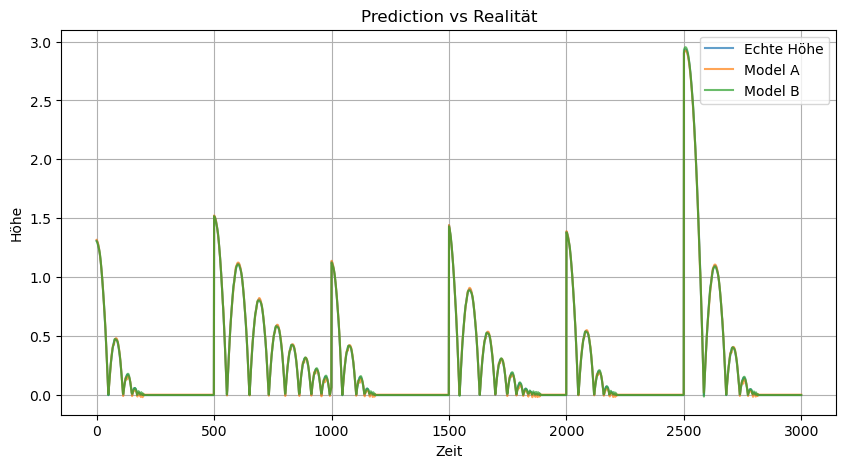

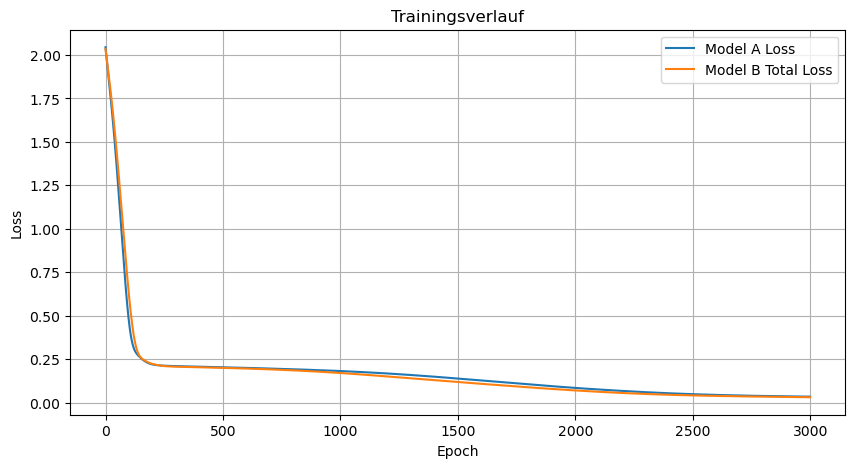

In [17]:
# Plot 1

y_test_np = y_test.numpy()
y_pred_a_np = y_test_pred_a.numpy()
y_pred_b_np = y_test_pred_b.numpy()

time = range(len(y_test_np))

plt.figure(figsize=(10, 5))
plt.plot(time, y_test_np[:, 0], label="Echte Höhe", alpha=0.7)
plt.plot(time, y_pred_a_np[:, 0], label="Model A", alpha=0.7)
plt.plot(time, y_pred_b_np[:, 0], label="Model B", alpha=0.7)
plt.xlabel("Zeit")
plt.ylabel("Höhe")
plt.title("Prediction vs Realität")
plt.legend()
plt.grid()
plt.show()

# Plot 2

plt.figure(figsize=(10, 5))
plt.plot(losses_a, label="Model A Loss")
plt.plot(losses_b, label="Model B Total Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Trainingsverlauf")
plt.legend()
plt.grid()
plt.show()